Using device: cuda
正在生成物理仿真数据...
开始训练 Koopman 模型...
✅ U_curr 与 X_curr 样本数匹配: 47904
✅ U_curr 与 X_curr 样本数匹配: 11976
Epoch [  10/50] | Train  total=2.0044e-02  pred=1.1859e-02  lifted=3.1093e-03| Val    total=2.1732e-02  pred=1.3518e-02  lifted=3.5447e-03
Epoch [  20/50] | Train  total=1.7713e-02  pred=1.0987e-02  lifted=2.9482e-03| Val    total=1.9334e-02  pred=1.2530e-02  lifted=3.3738e-03
Epoch [  30/50] | Train  total=1.6362e-02  pred=1.0367e-02  lifted=2.8373e-03| Val    total=1.8142e-02  pred=1.2039e-02  lifted=3.2843e-03
Epoch [  40/50] | Train  total=1.5855e-02  pred=1.0187e-02  lifted=2.7720e-03| Val    total=1.7726e-02  pred=1.1926e-02  lifted=3.2385e-03
Epoch [  50/50] | Train  total=1.5804e-02  pred=1.0201e-02  lifted=2.7707e-03| Val    total=1.7646e-02  pred=1.1907e-02  lifted=3.2274e-03
✅ Koopman模型构造完成 | A: (23, 23) | B: (23, 2) | C: (6, 23)
Simulation Done! Steps: 1667 | MPC Fails: 1667 | Time/Step: 0.0182s


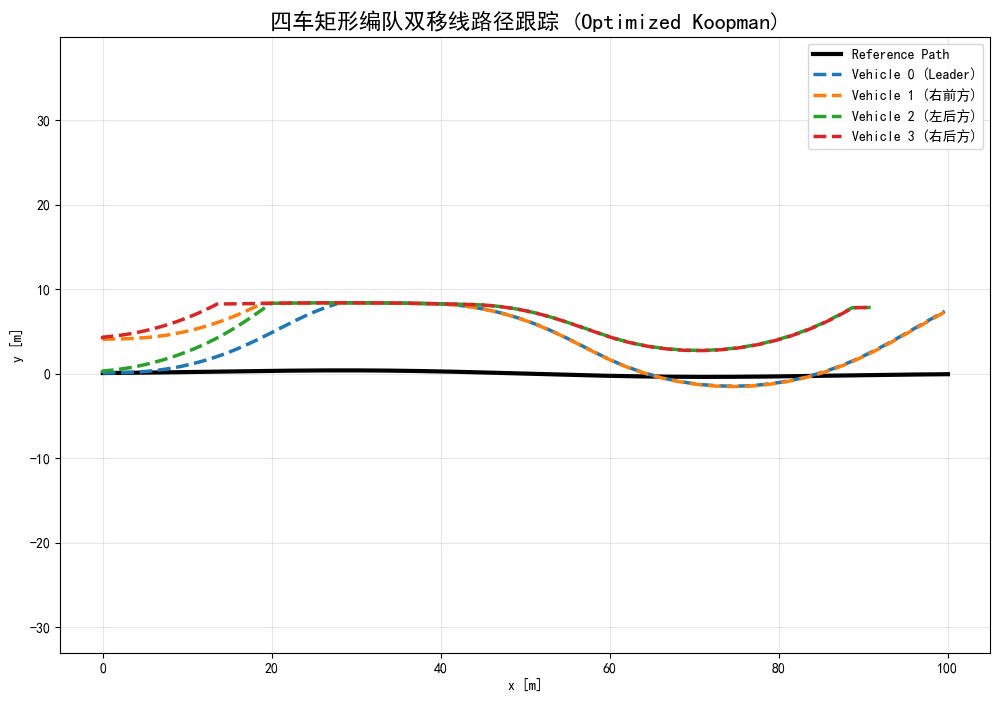

In [1]:
# =============================================================================
# 1. 导入依赖与辅助函数
# =============================================================================
import math
import os
import pickle
import random
import time
import itertools
import importlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.sparse as sparse

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# import Frenet-real-state dynamics file
import dynamics.cacalv3 as cacalv3

importlib.reload(cacalv3)
from dynamics.cacalv3 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt_four import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics_four import linear_Dynamics

# 修复中文乱码
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False


def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))
    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))
    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    return s_ref, psi_ref, np.nan_to_num(curvature_ref)


def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)
    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.array(x)


def clip_closed_loop_state(x, s_upper=500.0, s_lower=-30.0):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], s_lower, s_upper)
    x[1] = np.clip(x[1], -8.0, 8.0)
    x[2] = np.clip(x[2], -1.2, 1.2)
    x[3] = np.clip(x[3], 0.0, 10.0)
    x[4] = np.clip(x[4], -4.0, 4.0)
    x[5] = np.clip(x[5], -3.0, 3.0)
    return x


def is_finite_vector(x):
    return np.all(np.isfinite(np.asarray(x, dtype=float)))


def safe_FK_step(x, u, pars, SNR_DB, i, fallback_state=None, verbose=False):
    try:
        x_next = FK_solver(x, u, pars, sensor_noise=False, SNR_DB=SNR_DB, i=i)
    except Exception as e:
        return clip_closed_loop_state(fallback_state if fallback_state is not None else x)
    if not is_finite_vector(x_next):
        return clip_closed_loop_state(fallback_state if fallback_state is not None else x)
    return clip_closed_loop_state(x_next)


# =============================================================================
# 2. 数据生成与参数配置
# =============================================================================
num_states = 6
num_inputs = 2
dt = 0.02
sensor_noise = False
SNR_DB = 30
num_snaps = 500

sys_pars_base = {
    "num_states": num_states, "num_inputs": num_inputs, "dt": dt,
    "m": 1500.0, "Iz": 2250.0, "lf": 1.2, "lr": 1.6,
    "Cf": 80000.0, "Cr": 80000.0, "curvature_ref": 0.0,
    "uncertainty": "NA", "amp": 0.0, "seed": 42,
    "road_modes": ['dlc'], "road_mode_probs": [1.0],
    "u_modes": ['feedback_dominant', 'sinusoidal', 'mixed'],
    "u_mode_probs": [0.40, 0.30, 0.30],
    "alpha_u": 0.70, "s_margin": 15.0
}
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base.update({"m": 1650.0, "Iz": 2400.0, "Cf": 70000.0, "Cr": 70000.0})

configs = [
    {"vx_ref": 3.0, "delta_max": 0.10, "ax_max": 0.6, "freq": 1.0},
    {"vx_ref": 3.0, "delta_max": 0.20, "ax_max": 1.0, "freq": 0.5},
    {"vx_ref": 4.0, "delta_max": 0.15, "ax_max": 0.8, "freq": 0.2},
]
num_traj_per_batch = 40  # 为加快测试，稍微缩减轨迹数

X_list, X_changed_list, U_list = [], [], []
print("正在生成物理仿真数据...")
for cfg in configs:
    sp = dict(sys_pars_base);
    sp.update(cfg)
    sp_new = dict(sys_pars_new_base);
    sp_new.update(cfg)
    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise,
                                                          SNR_DB)
    X_list.append(X_b);
    X_changed_list.append(X_changed_b);
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]

# 打乱数据
indices = np.random.permutation(num_traj)
X, X_changed, U = X[indices], X_changed[indices], U[indices]

num_train = int(0.8 * num_traj)
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

# =============================================================================
# 3. Koopman 模型训练
# =============================================================================
net_params_lin = {
    "state_dim": num_states, "ctrl_dim": num_inputs,
    "encoder_hidden_width": 128, "encoder_hidden_depth": 4, "encoder_output_dim": 16,
    "optimizer": "adam", "activation_type": "tanh", "lr": 1e-4, "epochs": 50,  # 测试阶段可降低 epoch
    "batch_size": 4096, "eig_loss": True, "eig_loss_coeff": 0.5, "lifted_loss_penalty": 0.3,
    "l2_reg": 5e-5, "l1_reg": 1e-7, "first_obs_const": True, "override_C": True, "dt": dt
}

standardizer_u_kdnn = fit_standardizer(us_train, preprocessing.StandardScaler(with_mean=True))
standardizer_x_kdnn = fit_standardizer(xs_train, preprocessing.StandardScaler(with_mean=True))

print("开始训练 Koopman 模型...")
net = KoopmanNetCtrl_linear(net_params_lin, standardizer_x=standardizer_x_kdnn, standardizer_u=standardizer_u_kdnn,
                            device=DEVICE)
model_koop_dnn_lin = KoopDNN_linear(net)
model_koop_dnn_lin.set_datasets(xs_train, u_train=us_train, x_val=xs_val, u_val=us_val)
model_koop_dnn_lin.model_pipeline(net_params_lin)
model_koop_dnn_lin.construct_koopman_model()

# 提取矩阵并做稳定化投影
A_lin = to_numpy(model_koop_dnn_lin.net.A.weight)
B_lin = to_numpy(model_koop_dnn_lin.net.B.weight)
C_lin = to_numpy(model_koop_dnn_lin.net.C.weight)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999 for ev in eigvals])
A_lin_stable = np.real(eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs))

first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const if override_C else int(
    net_params_lin["encoder_output_dim"]) + first_obs_const

# =============================================================================
# 4. 参考轨迹生成
# =============================================================================
vx_nom = 3.0
path_length = 100.0
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

y_ref_path = (0.4 * np.exp(-0.5 * ((x_path - 30.0) / 16.0) ** 2)
              - 0.4 * np.exp(-0.5 * ((x_path - 70.0) / 16.0) ** 2))

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(x_path, y_ref_path)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

# =============================================================================
# 5. 多车 MPC 编队构建
# =============================================================================
NUM_VEHICLES = 4
DESIRED_LONGITUDINAL_GAP = 8.0
DESIRED_LATERAL_GAP = 4.0
Q_formation_weight = 800.0

formation_offsets = np.array([
    [0.0, 0.0],
    [0.0, DESIRED_LATERAL_GAP],
    [-DESIRED_LONGITUDINAL_GAP, 0.0],
    [-DESIRED_LONGITUDINAL_GAP, DESIRED_LATERAL_GAP]
])


def generate_formation_reference(x_ref_scaled, formation_offsets, standardizer_x):
    num_states_total = num_states * NUM_VEHICLES
    x_ref_formation = np.zeros((num_states_total, x_ref_scaled.shape[1]))
    for v in range(NUM_VEHICLES):
        offset_s = formation_offsets[v, 0]
        offset_ey = formation_offsets[v, 1]
        idx = v * num_states
        x_ref_formation[idx:idx + num_states, :] = x_ref_scaled.copy()
        x_ref_formation[idx + 0, :] += offset_s / standardizer_x.scale_[0]
        x_ref_formation[idx + 1, :] += offset_ey / standardizer_x.scale_[1]
    return x_ref_formation


x_ref_formation = generate_formation_reference(x_ref_scaled, formation_offsets, standardizer_x_kdnn)

# 单车基础权重
Q_mpc_lin_noadapt = sparse.diags([0.0, 1800.0, 600.0, 8.0, 1.0, 1.0])
QN_mpc_lin_noadapt = sparse.diags([0.0, 2500.0, 1200.0, 10.0, 1.0, 1.0])
R_mpc_lin_noadapt = sparse.diags([120.0, 12.0])

xmin_lin_noadapt = standardizer_x_kdnn.transform(
    np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0]).reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0]).reshape(1, -1)).flatten()
umin_lin_noadapt = np.array([-0.08, -1.0])
umax_lin_noadapt = np.array([0.08, 1.0])

nx = Q_mpc_lin_noadapt.shape[0]
Q_F_base = sparse.diags([Q_formation_weight, Q_formation_weight, 0.0, 0.0, 0.0, 0.0])

Q_blocks = [[None] * NUM_VEHICLES for _ in range(NUM_VEHICLES)]
QN_blocks = [[None] * NUM_VEHICLES for _ in range(NUM_VEHICLES)]
for i in range(NUM_VEHICLES):
    for j in range(NUM_VEHICLES):
        if i == j:
            coeff = (NUM_VEHICLES - 1) if i == 0 else 1
            Q_blocks[i][j] = Q_mpc_lin_noadapt + coeff * Q_F_base
            QN_blocks[i][j] = QN_mpc_lin_noadapt + coeff * Q_F_base
        elif i == 0 or j == 0:
            Q_blocks[i][j] = -Q_F_base
            QN_blocks[i][j] = -Q_F_base
        else:
            Q_blocks[i][j] = sparse.csc_matrix((nx, nx))
            QN_blocks[i][j] = sparse.csc_matrix((nx, nx))

Q_mpc_formation = sparse.bmat(Q_blocks, format='csc')
QN_mpc_formation = sparse.bmat(QN_blocks, format='csc')
R_mpc_formation = sparse.kron(sparse.eye(NUM_VEHICLES), R_mpc_lin_noadapt)

xmin_formation = np.tile(xmin_lin_noadapt, NUM_VEHICLES)
xmax_formation = np.tile(xmax_lin_noadapt, NUM_VEHICLES)
umin_formation = np.tile(umin_lin_noadapt, NUM_VEHICLES)
umax_formation = np.tile(umax_lin_noadapt, NUM_VEHICLES)

N_lin_noadapt = 80
max_iter_lin = 5

from scipy.sparse import block_diag as sparse_block_diag

A_block = sparse_block_diag([sparse.csc_matrix(A_lin_stable) for _ in range(NUM_VEHICLES)], format='csc')
B_block = sparse_block_diag([sparse.csc_matrix(B_lin) for _ in range(NUM_VEHICLES)], format='csc')
C_block = sparse_block_diag([sparse.csc_matrix(C_lin) for _ in range(NUM_VEHICLES)], format='csc')

linear_model_formation = linear_Dynamics(A_block, B_block, C_block)

solver_settings = {
    "gen_embedded_ctrl": False, "warm_start": True, "polish": True, "polish_refine_iter": 5,
    "scaling": True, "adaptive_rho": True, "check_termination": 25, "max_iter": 4000,
    "eps_abs": 1e-3, "eps_rel": 1e-3, "eps_prim_inf": 1e-3, "eps_dual_inf": 1e-3
}

controller_nmpc_formation = NonlinearMPCController(
    linear_model_formation, N_lin_noadapt, dt, umin_formation, umax_formation,
    xmin_formation, xmax_formation, Q_mpc_formation, R_mpc_formation, QN_mpc_formation, solver_settings
)

z_init_formation = np.zeros((N_lin_noadapt + 1, n_obs_lin * NUM_VEHICLES))
u_init_formation = np.zeros((N_lin_noadapt, num_inputs * NUM_VEHICLES))
x_ref_init_2d = np.hstack([x_ref_formation, np.repeat(x_ref_formation[:, -1:], N_lin_noadapt + 1, axis=1)])[
    :, :N_lin_noadapt + 1]
controller_nmpc_formation.construct_controller(z_init=z_init_formation, u_init=u_init_formation, x_ref=x_ref_init_2d)

# =============================================================================
# 6. 四车闭环仿真与绘图
# =============================================================================
num_states_total = num_states * NUM_VEHICLES
num_inputs_total = num_inputs * NUM_VEHICLES

xt_actual_formation = np.zeros((traj_length, num_states_total))
u_formation = np.zeros((traj_length - 1, num_inputs_total))
z_formation = np.zeros((traj_length, n_obs_lin * NUM_VEHICLES))

for v in range(NUM_VEHICLES):
    idx = v * num_states
    xt_actual_formation[0, idx:idx + num_states] = np.array([
        formation_offsets[v, 0], formation_offsets[v, 1], 0.0, vx_nom, 0.0, 0.0
    ])

begin_formation = time.time()
fail_count = 0

sys_pars_ctrl = dict(sys_pars_new_base)
sys_pars_ctrl.update({"vx_ref": vx_nom, "uncertainty": "NA", "amp": 0.0, "freq": 1.0,
                      "s_ref": s_ref_path, "curvature_ref": curvature_ref_path})

for k in range(traj_length - 1):
    xk_raw_total = xt_actual_formation[k, :].copy()

    for v in range(NUM_VEHICLES):
        idx = v * num_states
        xk_raw_total[idx:idx + num_states] = clip_closed_loop_state(xk_raw_total[idx:idx + num_states])

    if not is_finite_vector(xk_raw_total):
        print(f"[STOP] Non-finite state at step {k}");
        break

    try:
        z_current = np.zeros(n_obs_lin * NUM_VEHICLES)
        for v in range(NUM_VEHICLES):
            idx = v * num_states
            x_v_scaled = standardizer_x_kdnn.transform(xk_raw_total[idx:idx + num_states].reshape(1, -1)).flatten()
            z_current[v * n_obs_lin:(v + 1) * n_obs_lin] = lift_scaled(x_v_scaled, model_koop_dnn_lin, net_params_lin)
        z_formation[k, :] = z_current
    except Exception as e:
        print(f"[STOP] Lift failed at step {k}");
        break

    end_idx = k + 1 + N_lin_noadapt + 1
    if end_idx <= x_ref_formation.shape[1]:
        xref_win = x_ref_formation[:, k + 1: end_idx]
    else:
        pad_len = (N_lin_noadapt + 1) - (x_ref_formation.shape[1] - (k + 1))
        xref_win = np.hstack([x_ref_formation[:, k + 1:], np.tile(x_ref_formation[:, -1:], (1, pad_len))])

    try:
        controller_nmpc_formation.solve_to_convergence(
            xref_win, z_formation[k, :], controller_nmpc_formation.z_init, controller_nmpc_formation.u_init,
            max_iter=max_iter_lin, eps=1e-3
        )
        controller_nmpc_formation.update_initial_guess_()
        u_mpc = controller_nmpc_formation.cur_u.flatten()[:num_inputs_total]
    except Exception as e:
        fail_count += 1
        u_mpc = u_formation[k - 1, :] if k > 0 else np.zeros(num_inputs_total)

    for v in range(NUM_VEHICLES):
        idx_u, idx_s = v * num_inputs, v * num_states
        s_current = xt_actual_formation[k, idx_s]
        idx_curv = np.argmin(np.abs(s_ref_path - s_current))
        delta_ff = 0.8 * (sys_pars_base["lf"] + sys_pars_base["lr"]) * curvature_ref_path[idx_curv]

        delta_cmd_raw = np.clip(float(u_mpc[idx_u]) + delta_ff, umin_formation[idx_u], umax_formation[idx_u])
        ax_cmd = np.clip(float(u_mpc[idx_u + 1]), umin_formation[idx_u + 1], umax_formation[idx_u + 1])

        if k > 0:
            delta_cmd_raw = 0.6 * u_formation[k - 1, idx_u] + 0.4 * delta_cmd_raw
            ax_cmd = 0.5 * u_formation[k - 1, idx_u + 1] + 0.5 * ax_cmd

        u_formation[k, idx_u:idx_u + 2] = [delta_cmd_raw, ax_cmd]

    for v in range(NUM_VEHICLES):
        idx = v * num_states
        u_v = u_formation[k, v * num_inputs:(v + 1) * num_inputs]
        x_v = xt_actual_formation[k, idx:idx + num_states]
        fallback = x_v.copy() if k > 0 else xt_actual_formation[0, idx:idx + num_states]
        xt_actual_formation[k + 1, idx:idx + num_states] = safe_FK_step(x_v, u_v, sys_pars_ctrl, SNR_DB, k, fallback)

print(
    f"Simulation Done! Steps: {traj_length - 1} | MPC Fails: {fail_count} | Time/Step: {(time.time() - begin_formation) / (traj_length - 1):.4f}s")

# 绘图
valid_len = traj_length
for idx in range(traj_length):
    if not np.all(np.isfinite(xt_actual_formation[idx, :])):
        valid_len = idx;
        break

plt.figure(figsize=(12, 8))
plt.plot(x_path, y_ref_path, 'k-', linewidth=3, label="Reference Path")
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
labels = ['Vehicle 0 (Leader)', 'Vehicle 1 (右前方)', 'Vehicle 2 (左后方)', 'Vehicle 3 (右后方)']

for v in range(NUM_VEHICLES):
    idx = v * num_states
    x_actual, y_actual = frenet_to_global(xt_actual_formation[:valid_len, idx],
                                          xt_actual_formation[:valid_len, idx + 1], s_ref_path, x_path, y_ref_path,
                                          psi_ref_path)
    plt.plot(x_actual, y_actual, '--', color=colors[v], linewidth=2.5, label=labels[v])

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("四车矩形编队双移线路径跟踪 (Optimized Koopman)", fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()